# Event Review

Two-step workflow:
1. Set `STATE` and run **Load state data** once — downloads all blobs.
2. Set `YEAR` and run **Select year** + the three plot cells — fast slice of cached data.

In [ ]:
import sys
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("../../../..")
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv  # noqa: E402

load_dotenv(ROOT / ".env")

import ocha_stratus as stratus  # noqa: E402

from src.constants import PROJECT_PREFIX, STATE_CONFIG  # noqa: E402
from src.datasources import grrr  # noqa: E402
from src.datasources.glofas import get_blob_name  # noqa: E402

In [ ]:
STATE = "Adamawa"  # "Adamawa" or "Benue"

WET_MONTHS = [8, 9, 10, 11]
RP_LEVELS  = [3, 4, 5]
RP_COLORS  = {3: "#74ADD1", 4: "#F46D43", 5: "#D73027"}

cfg = STATE_CONFIG[STATE]

## Load state data

_Run once. Re-run only when `STATE` changes._

In [ ]:
# ── Trigger matrix ───────────────────────────────────────────────────────────
tm_blob = (
    f"{PROJECT_PREFIX}/processed/trigger_matrix"
    f"/{STATE.lower()}_trigger_matrix.parquet"
)
df_tm = stratus.load_parquet_from_blob(tm_blob)

# ── Floodscan daily mean SFED (all years) ────────────────────────────────────
df_fs_raw = stratus.load_parquet_from_blob(cfg["floodscan_blob"])
df_fs_raw["date"] = pd.to_datetime(df_fs_raw["date"])

df_fs = (
    df_fs_raw.groupby("date")["SFED"]
    .mean()
    .reset_index()
    .rename(columns={"SFED": "sfed"})
)
df_fs["year"]  = df_fs["date"].dt.year
df_fs["month"] = df_fs["date"].dt.month
df_fs["mmdd"]  = df_fs["date"].dt.strftime("%m-%d")

analysis_years = range(cfg["analysis_start_year"], cfg["analysis_end_year"] + 1)
df_fs_wet = df_fs[
    df_fs["month"].isin(WET_MONTHS) & df_fs["year"].isin(analysis_years)
].copy()
ann_max = df_fs_wet.groupby("year")["sfed"].max()

# ── GloFAS reforecast (all years) ────────────────────────────────────────────
df_rf = stratus.load_parquet_from_blob(cfg["glofas_reforecast_blob"])
df_rf["time"] = pd.to_datetime(df_rf["time"])

# ── GloFAS reanalysis (all years) ────────────────────────────────────────────
ra_blob = get_blob_name("processed", "reanalysis", cfg["glofas_station"])
df_ra   = stratus.load_parquet_from_blob(ra_blob)
df_ra["time"] = pd.to_datetime(df_ra["time"])
dis_col = next(c for c in df_ra.columns if c.lower() in ("dis24", "discharge"))

# ── GRRR top-10 gauges (all years) ───────────────────────────────────────────
top10_blob = (
    f"{PROJECT_PREFIX}/processed/model_comparison"
    f"/{STATE.lower()}_top10_gauges.parquet"
)
gauge_ids = stratus.load_parquet_from_blob(top10_blob)["gauge_id"].tolist()

ds_grrr = grrr.load_reanalysis(gauge=gauge_ids)
df_grrr = grrr.process_reanalysis(ds_grrr)
df_grrr["date"]  = pd.to_datetime(df_grrr["valid_time"]).dt.normalize()
df_grrr["month"] = df_grrr["date"].dt.month

ds_rp = grrr.load_return_periods(gauge=gauge_ids)
df_rp = ds_rp.to_dataframe().reset_index()

glofas_thresh = cfg["glofas_thresh"]
print(f"State data loaded for {STATE}")

## Select year

_Change `YEAR` and re-run this cell and the plot cells below._

In [9]:
YEAR = 2022

# ── RP thresholds from trigger matrix ────────────────────────────────────────
rp_thresh = {}
for rp in RP_LEVELS:
    ev = [y for y in df_tm[df_tm[f"fs_{rp}yr"] == 1]["year"] if y in ann_max.index]
    if ev:
        rp_thresh[rp] = float(ann_max.loc[ev].min())

# ── Slice all datasets to YEAR ────────────────────────────────────────────────
rf_year = df_rf[
    (df_rf["time"].dt.year == YEAR)
    & df_rf["time"].dt.month.isin(WET_MONTHS)
    & df_rf["leadtime"].between(1, 16)
].copy()

rf_ens = (
    rf_year.groupby(["time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
    .rename(columns={"time": "issue_date", "dis24": "ens_mean"})
)
rf_ens["valid_date"] = (
    rf_ens["issue_date"] + pd.to_timedelta(rf_ens["leadtime"], unit="D")
)

df_ra_year = df_ra[
    (df_ra["time"].dt.year == YEAR) & df_ra["time"].dt.month.isin(WET_MONTHS)
].sort_values("time")

df_grrr_year = df_grrr[
    (df_grrr["date"].dt.year == YEAR) & df_grrr["month"].isin(WET_MONTHS)
].copy()

# ── Event summary ─────────────────────────────────────────────────────────────
if YEAR in df_tm["year"].values:
    tm_row = df_tm[df_tm["year"] == YEAR].iloc[0]
    is_event = {rp: bool(tm_row[f"fs_{rp}yr"]) for rp in RP_LEVELS}
else:
    is_event = {rp: "no data" for rp in RP_LEVELS}

thresh_str = {rp: round(v, 4) for rp, v in rp_thresh.items()}
print(f"{STATE}  —  {YEAR}")
print(f"  GloFAS threshold     : {glofas_thresh:,} m\u00b3/s")
print(f"  Floodscan thresholds : {thresh_str}")
print(f"  Flood event          : {is_event}")

Adamawa  —  2022
  GloFAS threshold     : 3,132 m³/s
  Floodscan thresholds : {3: 0.1409, 4: 0.1651, 5: 0.1934}
  Flood event          : {3: True, 4: True, 5: True}


## 1. Floodscan SFED

Daily mean SFED for the selected year (blue) against the historical percentile band and RP thresholds.

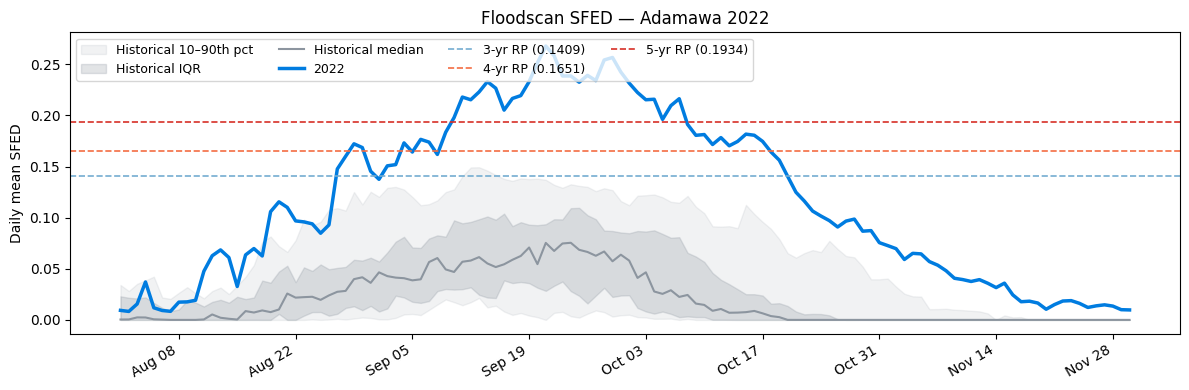

In [10]:
# Align historical years by month-day so Aug 15 in any year maps to Aug 15 of YEAR
mmdd_to_date = (
    df_fs_wet[df_fs_wet["year"] == YEAR]
    .set_index("mmdd")["date"]
    .to_dict()
)

hist = df_fs_wet[df_fs_wet["year"] != YEAR]
hist_stats = (
    hist.groupby("mmdd")["sfed"]
    .agg(
        q10=lambda x: x.quantile(0.1),
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.9),
    )
    .reset_index()
)
hist_stats["date"] = hist_stats["mmdd"].map(mmdd_to_date)
hist_stats = hist_stats.dropna(subset=["date"]).sort_values("date")

yr = df_fs_wet[df_fs_wet["year"] == YEAR].sort_values("date")

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(
    hist_stats["date"], hist_stats["q10"], hist_stats["q90"],
    color="#8c959f", alpha=0.12, label="Historical 10\u201390th pct",
)
ax.fill_between(
    hist_stats["date"], hist_stats["q25"], hist_stats["q75"],
    color="#8c959f", alpha=0.25, label="Historical IQR",
)
ax.plot(hist_stats["date"], hist_stats["median"],
        color="#8c959f", lw=1.5, label="Historical median")
ax.plot(yr["date"], yr["sfed"],
        color="#007CE0", lw=2.5, label=str(YEAR))

for rp, thr in rp_thresh.items():
    ax.axhline(thr, color=RP_COLORS[rp], lw=1.2, ls="--",
               label=f"{rp}-yr RP ({thr:.4f})")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel("Daily mean SFED")
ax.set_title(f"Floodscan SFED \u2014 {STATE} {YEAR}")
ax.legend(fontsize=9, ncol=4, loc="upper left")
fig.tight_layout()
plt.show()

## 2. GloFAS Reforecast

Each line is the ensemble-mean forecast from one issue date during the wet season. Lines are coloured from light (early season) to dark (late season). The black line is the reanalysis.

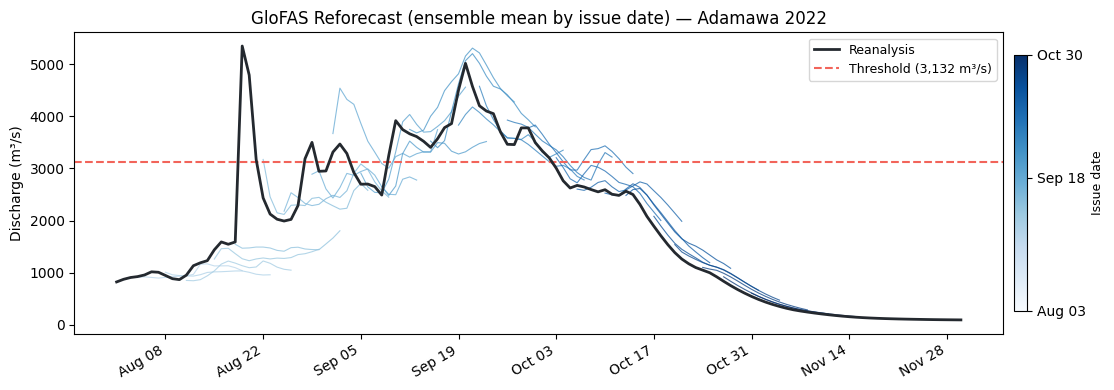

In [11]:
issue_dates = sorted(rf_ens["issue_date"].unique())
n = len(issue_dates)
palette = cm.Blues(np.linspace(0.3, 1.0, max(n, 1)))

fig, ax = plt.subplots(figsize=(12, 4))

for (issue_dt, grp), color in zip(rf_ens.groupby("issue_date"), palette):
    grp = grp.sort_values("valid_date")
    ax.plot(grp["valid_date"], grp["ens_mean"],
            color=color, lw=0.8, alpha=0.75)

ax.plot(
    df_ra_year["time"], df_ra_year[dis_col],
    color="#24292f", lw=2, label="Reanalysis", zorder=5,
)
ax.axhline(
    glofas_thresh, color="#F2645A", lw=1.5, ls="--",
    label=f"Threshold ({glofas_thresh:,} m\u00b3/s)",
)

if n > 1:
    sm = plt.cm.ScalarMappable(
        cmap="Blues", norm=plt.Normalize(vmin=0, vmax=n - 1)
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, shrink=0.85)
    cbar.set_ticks([0, n // 2, n - 1])
    cbar.set_ticklabels([
        issue_dates[0].strftime("%b %d"),
        issue_dates[n // 2].strftime("%b %d"),
        issue_dates[-1].strftime("%b %d"),
    ])
    cbar.set_label("Issue date", fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel("Discharge (m\u00b3/s)")
ax.set_title(
    f"GloFAS Reforecast (ensemble mean by issue date) \u2014 {STATE} {YEAR}"
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 3. GRRR Gauge Signals

Wet-season streamflow for each of the top-10 gauges. Dashed lines are Google official RP thresholds (2-, 5-, 7-yr).

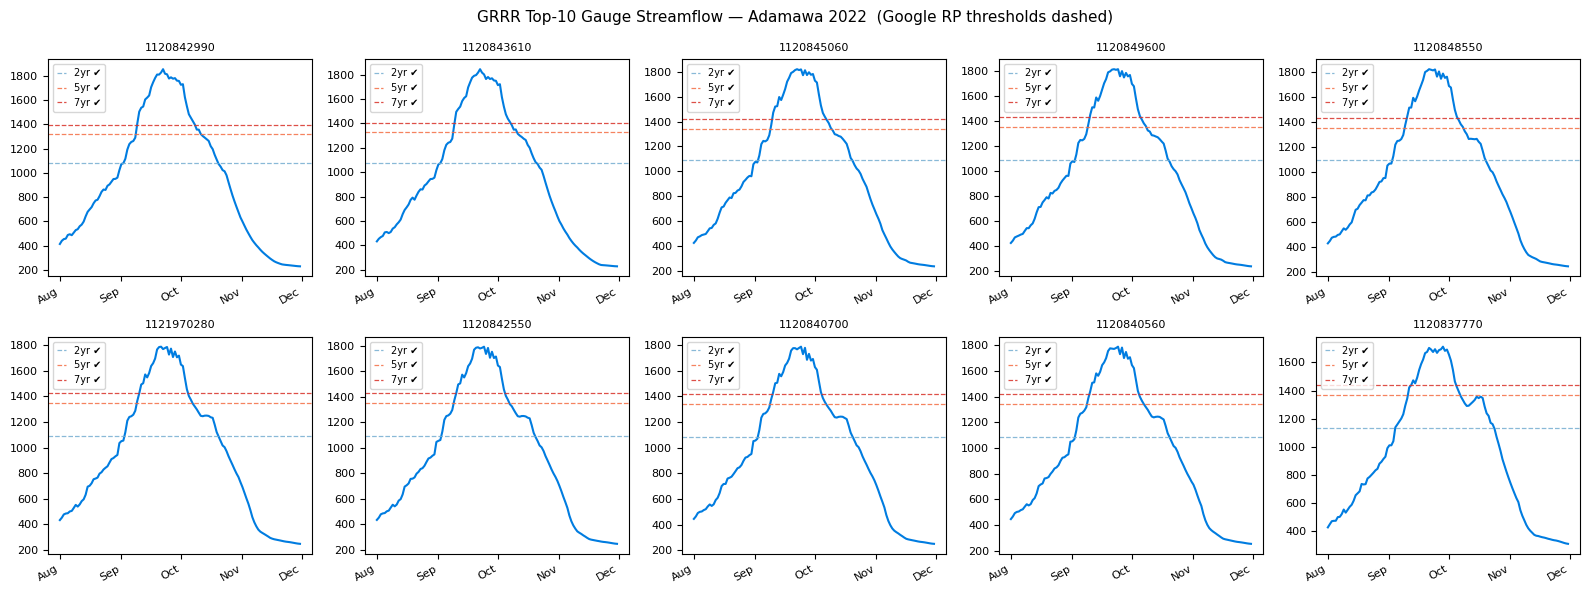

In [12]:
google_rp_colors = {"2": "#74ADD1", "5": "#F46D43", "7": "#D73027"}

ncols = 5
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), sharey=False)
axes = axes.flatten()

for i, gid in enumerate(gauge_ids):
    ax = axes[i]
    g = df_grrr_year[df_grrr_year["gauge_id"] == gid].sort_values("date")
    ax.plot(g["date"], g["streamflow"], color="#007CE0", lw=1.5)

    rp_row = df_rp[df_rp["gauge_id"] == gid]
    for rp_yr, col in google_rp_colors.items():
        rp_col = f"return_period_{rp_yr}"
        if rp_col in rp_row.columns and len(rp_row):
            val = rp_row[rp_col].values[0]
            exceeded = (g["streamflow"] >= val).any()
            ax.axhline(
                val, color=col, lw=0.9, ls="--", alpha=0.85,
                label=f"{rp_yr}yr" + (" \u2714" if exceeded else ""),
            )

    ax.set_title(gid.replace("hybas_", ""), fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=7, loc="upper left", handlelength=1)

for j in range(len(gauge_ids), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"GRRR Top-10 Gauge Streamflow \u2014 {STATE} {YEAR}  (Google RP thresholds dashed)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 4. Combined overview

All three sources on a shared time axis. GRRR gauge traces are normalised by each gauge's 5-yr RP threshold (fallback: 7-yr, then 2-yr), so the dashed line at 1.0 marks exceedance. The black line is the cross-gauge median.

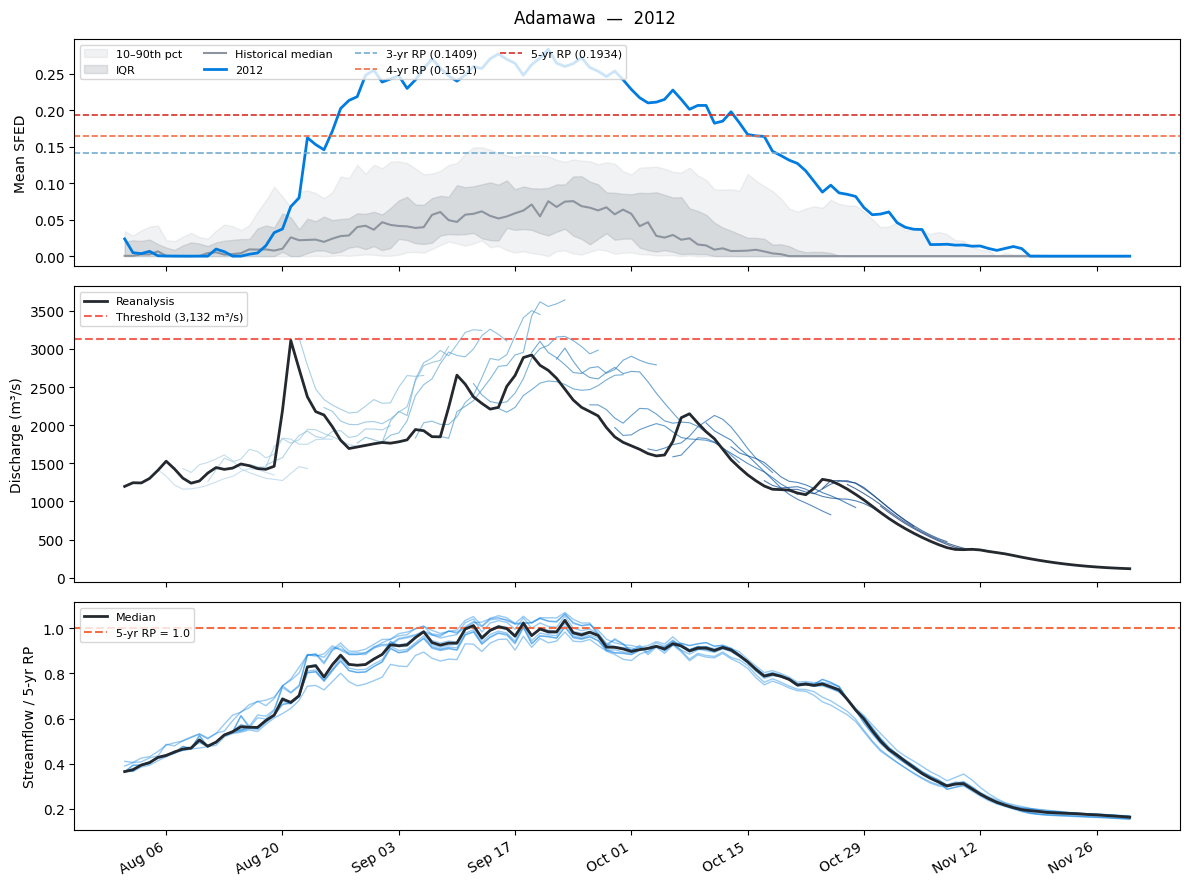

In [8]:
# ── Floodscan historical stats for the selected year ─────────────────────────
_mmdd_to_date = (
    df_fs_wet[df_fs_wet["year"] == YEAR]
    .set_index("mmdd")["date"]
    .to_dict()
)
_hist = df_fs_wet[df_fs_wet["year"] != YEAR]
_hist_stats = (
    _hist.groupby("mmdd")["sfed"]
    .agg(
        q10=lambda x: x.quantile(0.1),
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.9),
    )
    .reset_index()
)
_hist_stats["date"] = _hist_stats["mmdd"].map(_mmdd_to_date)
_hist_stats = _hist_stats.dropna(subset=["date"]).sort_values("date")
_yr = df_fs_wet[df_fs_wet["year"] == YEAR].sort_values("date")

# ── Normalise GRRR traces by 5-yr RP (fallback: 7-yr, then 2-yr) ─────────────
_norm_dfs = []
for _gid in gauge_ids:
    _g = df_grrr_year[df_grrr_year["gauge_id"] == _gid][["date", "streamflow"]].copy()
    _rp_row = df_rp[df_rp["gauge_id"] == _gid]
    _ref = None
    for _col in ["return_period_5", "return_period_7", "return_period_2"]:
        if _col in _rp_row.columns and len(_rp_row) and pd.notna(_rp_row[_col].values[0]):
            _ref = float(_rp_row[_col].values[0])
            break
    if _ref and _ref > 0 and len(_g):
        _g = _g.copy()
        _g["normed"] = _g["streamflow"] / _ref
        _norm_dfs.append(_g[["date", "normed"]])

_df_norm_all = pd.concat(_norm_dfs) if _norm_dfs else pd.DataFrame(columns=["date", "normed"])
_df_norm_med = _df_norm_all.groupby("date")["normed"].median().reset_index()

# ── 3-panel figure ────────────────────────────────────────────────────────────
fig, (ax_fs, ax_gf, ax_gr) = plt.subplots(
    3, 1, figsize=(12, 9), sharex=True,
    gridspec_kw={"height_ratios": [1, 1.3, 1]},
)
fig.suptitle(f"{STATE}  —  {YEAR}", fontsize=12)

# — Panel 1: Floodscan SFED —
ax_fs.fill_between(
    _hist_stats["date"], _hist_stats["q10"], _hist_stats["q90"],
    color="#8c959f", alpha=0.12, label="10–90th pct",
)
ax_fs.fill_between(
    _hist_stats["date"], _hist_stats["q25"], _hist_stats["q75"],
    color="#8c959f", alpha=0.25, label="IQR",
)
ax_fs.plot(_hist_stats["date"], _hist_stats["median"],
           color="#8c959f", lw=1.5, label="Historical median")
ax_fs.plot(_yr["date"], _yr["sfed"], color="#007CE0", lw=2, label=str(YEAR))
for _rp, _thr in rp_thresh.items():
    ax_fs.axhline(_thr, color=RP_COLORS[_rp], lw=1.2, ls="--",
                  label=f"{_rp}-yr RP ({_thr:.4f})")
ax_fs.set_ylabel("Mean SFED")
ax_fs.legend(fontsize=8, ncol=4, loc="upper left")

# — Panel 2: GloFAS reforecast + reanalysis —
_issue_dates = sorted(rf_ens["issue_date"].unique())
_n = len(_issue_dates)
_palette = cm.Blues(np.linspace(0.3, 1.0, max(_n, 1)))
for (_iss, _grp), _col in zip(rf_ens.groupby("issue_date"), _palette):
    _grp = _grp.sort_values("valid_date")
    ax_gf.plot(_grp["valid_date"], _grp["ens_mean"], color=_col, lw=0.8, alpha=0.7)
ax_gf.plot(df_ra_year["time"], df_ra_year[dis_col],
           color="#24292f", lw=2, label="Reanalysis", zorder=5)
ax_gf.axhline(glofas_thresh, color="#F2645A", lw=1.5, ls="--",
              label=f"Threshold ({glofas_thresh:,} m³/s)")
ax_gf.set_ylabel("Discharge (m³/s)")
ax_gf.legend(fontsize=8, loc="upper left")

# — Panel 3: GRRR gauges normalised by 5-yr RP —
for _gid in gauge_ids:
    _g = df_grrr_year[df_grrr_year["gauge_id"] == _gid].sort_values("date")
    _rp_row = df_rp[df_rp["gauge_id"] == _gid]
    _ref = None
    for _col in ["return_period_5", "return_period_7", "return_period_2"]:
        if _col in _rp_row.columns and len(_rp_row) and pd.notna(_rp_row[_col].values[0]):
            _ref = float(_rp_row[_col].values[0])
            break
    if _ref and _ref > 0 and len(_g):
        ax_gr.plot(_g["date"], _g["streamflow"] / _ref,
                   color="#007CE0", lw=1, alpha=0.4)
if not _df_norm_med.empty:
    ax_gr.plot(_df_norm_med["date"], _df_norm_med["normed"],
               color="#24292f", lw=2, label="Median", zorder=5)
ax_gr.axhline(1.0, color="#F46D43", lw=1.5, ls="--", label="5-yr RP = 1.0")
ax_gr.set_ylabel("Streamflow / 5-yr RP")
ax_gr.legend(fontsize=8, loc="upper left")

# — Shared x-axis formatting —
ax_gr.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_gr.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_gr.xaxis.get_majorticklabels(), rotation=30, ha="right")

fig.tight_layout()
plt.show()